In [1]:
import pandas as pd
pd.set_option('display.max_columns', 10)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, HTML
import re
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize
from sklearn.pipeline import Pipeline
import joblib

In [2]:
df =pd.read_parquet('books.parquet')
df = df.sample(frac=0.4)
data  = df.copy()
df.shape

(10000, 25)

In [3]:
#info
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 13885 to 22466
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            10000 non-null  str    
 1   title             10000 non-null  str    
 2   series            4992 non-null   str    
 3   author            10000 non-null  str    
 4   rating            10000 non-null  float64
 5   description       9706 non-null   str    
 6   language          9109 non-null   str    
 7   isbn              10000 non-null  str    
 8   genres            10000 non-null  str    
 9   characters        10000 non-null  str    
 10  bookFormat        9695 non-null   str    
 11  edition           1010 non-null   str    
 12  pages             9449 non-null   str    
 13  publisher         9137 non-null   str    
 14  publishDate       9832 non-null   str    
 15  firstPublishDate  5429 non-null   str    
 16  awards            10000 non-null  str    
 17  numRa

In [4]:
# null values can be seen, let's check
df.isna().sum()

bookId                 0
title                  0
series              5008
author                 0
rating                 0
description          294
language             891
isbn                   0
genres                 0
characters             0
bookFormat           305
edition             8990
pages                551
publisher            863
publishDate          168
firstPublishDate    4571
awards                 0
numRatings             0
ratingsByStars         0
likedPercent         150
setting                0
coverImg             121
bbeScore               0
bbeVotes               0
price               3211
dtype: int64

In [5]:
#head
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
13885,19189005-the-river-folk,The River Folk,NaN,Margaret Dickinson,4.22,...,[],https://i.gr-assets.com/images/S/compressed.ph...,34,1,3.11
18291,3606415-how-to-survive-in-your-native-land,How to Survive in Your Native Land,NaN,James Herndon,4.15,...,[],https://i.gr-assets.com/images/S/compressed.ph...,42,1,5.87


In [6]:
#duplicates by title and author
df.duplicated(subset= [ 'title' , 'author']).sum()

np.int64(11)

In [7]:
#check those duplicates
df[df.duplicated(subset= [ 'title' , 'author'])]

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
3566,23394408-die-unendlichkeit-schl-ft,Die Unendlichkeit schläft,Loki von Schallern Staffel 1 #3,Melanie Meier,4.50,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
10645,1524173.The_Sorcerer_of_the_North,The Sorcerer of the North,Ranger's Apprentice #5,John Flanagan,4.27,...,[],https://i.gr-assets.com/images/S/compressed.ph...,1786,25,7.65
24282,8538135-catfancy-s-naughty-no-more-change-unwa...,CATFANCY's Naughty No More! Change Unwanted Be...,NaN,Marilyn Krieger,4.06,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,5.36
2348,23590446-how-to-fight-a-dragon-s-fury,How to Fight a Dragon’s Fury,How to Train Your Dragon #12,Cressida Cowell,4.59,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
2662,25454580,বাংলাদেশের কিংবদন্তী,NaN,শামসুল ইসলাম,4.56,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
21454,15757665-s-u-ng-i-i-kh-p-th-gian,Sáu Người Đi Khắp Thế Gian,Sáu Người Đi Khắp Thế Gian #1,"James A. Michener, Nguyễn Thị Bạch Tuyết (Tran...",4.10,...,[],https://i.gr-assets.com/images/S/compressed.ph...,95,1,NaN
19700,345627.Vampire_Academy,Vampire Academy,Vampire Academy #1,Richelle Mead (Goodreads Author),4.12,...,['Montana (United States)'],https://i.gr-assets.com/images/S/compressed.ph...,277801,2986,3.33
8657,17999135-exposure,Exposure,Virals #4,"Kathy Reichs (Goodreads Author), Brendan Reich...",4.32,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,2.77
10994,975953.Time_of_the_Dragons,Time of the Dragons,Shike #1,Robert Shea,4.27,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,5.45
1974,9647295-the-way-of-kings,The Way of Kings,The Stormlight Archive #1,Brandon Sanderson (Goodreads Author),4.63,...,['Roshar'],https://i.gr-assets.com/images/S/compressed.ph...,100,1,8.57


In [8]:
#drop duplicates
df.drop_duplicates(subset= [ 'title' , 'author'], keep = 'first', inplace = True)

# EDA

In [9]:
# all categorical columns
df.select_dtypes(include = ['str','object']).head(2)

,bookId,title,series,author,description,...,awards,ratingsByStars,setting,coverImg,price
13885,19189005-the-river-folk,The River Folk,NaN,Margaret Dickinson,The River Folk is a spellbinding story of Linc...,...,[],"['70', '28', '24', '6', '2']",[],https://i.gr-assets.com/images/S/compressed.ph...,3.11
18291,3606415-how-to-survive-in-your-native-land,How to Survive in Your Native Land,NaN,James Herndon,In How to Survive in Your Native Land James He...,...,[],"['55', '31', '20', '3', '4']",[],https://i.gr-assets.com/images/S/compressed.ph...,5.87


In [10]:
# columns : pages and price are of string types where as it should be numerical,
df['pages'] = pd.to_numeric(df['pages'], errors = 'coerce') #pages will be converted to float
df['price'] = pd.to_numeric(df['price'], errors = 'coerce') #price will be converted to float

In [11]:
# numerical columns
df.select_dtypes(include = ['number']).head(2)

,rating,pages,numRatings,likedPercent,bbeScore,bbeVotes,price
13885,4.22,464.0,130,94.0,34,1,3.11
18291,4.15,192.0,113,94.0,42,1,5.87


In [12]:
# Let's plot images of the top 30 books with highest liked percentage

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Highest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent', ascending=False).head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [13]:
# Let's plot images of the top 30 books with lowest likedPercent

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Lowest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent').head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [14]:
df['bookFormat'].value_counts()

bookFormat
Paperback                      4831
Hardcover                      2214
Kindle Edition                 1374
ebook                           582
Mass Market Paperback           459
Audio CD                         35
Nook                             32
Audiobook                        25
Unknown Binding                  22
Audible Audio                     9
Board Book                        7
Trade Paperback                   7
Audio                             6
Audio Cassette                    6
Leather Bound                     5
paperback                         5
Boxed Set                         5
Library Binding                   5
Board book                        5
Comics                            4
Capa dura                         3
Online                            3
Slipcased Hardcover               2
Graphic Novels                    2
hardcover                         2
MP3 CD                            2
paper                             2
Taschenbuch      

In [15]:
# plotting 20 most expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Most Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=False).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [16]:
df.sort_values(by='price', ascending=True).head(20)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
13696,160629.A_Bear_Called_Paddington,A Bear Called Paddington,Paddington Bear #1,"Michael Bond, Peggy Fortnum (Illustrator)",4.22,...,[],https://i.gr-assets.com/images/S/compressed.ph...,93,1,0.84
22366,792159.The_Butterfly_Lion,The Butterfly Lion,NaN,"Michael Morpurgo, Christian Birmingham (Illust...",4.09,...,['South Africa'],https://i.gr-assets.com/images/S/compressed.ph...,47,2,0.84
19545,515394.Twilight_Illusions,Twilight Illusions,Wings in the Night #3,Maggie Shayne (Goodreads Author),4.13,...,['United States of America'],https://i.gr-assets.com/images/S/compressed.ph...,81,1,0.84
16854,28789256-the-secret,The Secret,NaN,Kathryn Hughes,4.17,...,[],https://i.gr-assets.com/images/S/compressed.ph...,90,1,0.84
19638,297866.Holy_Smokes,Holy Smokes,Aisling Grey #4,Katie MacAlister (Goodreads Author),4.13,...,"['London, England']",https://i.gr-assets.com/images/S/compressed.ph...,55,1,0.84
18971,3551831-the-first-adventure,The First Adventure,Tumtum and Nutmeg #1,Emily Bearn,4.14,...,[],https://i.gr-assets.com/images/S/compressed.ph...,46,1,0.84
15650,3430269-mortal-sins,Mortal Sins,World of the Lupi #5,Eileen Wilks (Goodreads Author),4.19,...,[],https://i.gr-assets.com/images/S/compressed.ph...,57,1,0.84
8237,17853024-the-pagan-lord,The Pagan Lord,The Last Kingdom #7,Bernard Cornwell (Goodreads Author),4.33,...,[],https://i.gr-assets.com/images/S/compressed.ph...,81,1,0.84
15480,308532.Soft_Target,Soft Target,Dan Shepherd #2,Stephen Leather (Goodreads Author),4.19,...,[],https://i.gr-assets.com/images/S/compressed.ph...,94,1,0.84
9586,3029095-the-last-summer,The Last Summer,Adams Family Saga #11,Mary Jane Staples,4.30,...,[],https://i.gr-assets.com/images/S/compressed.ph...,82,1,0.84


In [17]:
# plotting 20 least expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Least Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=True).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


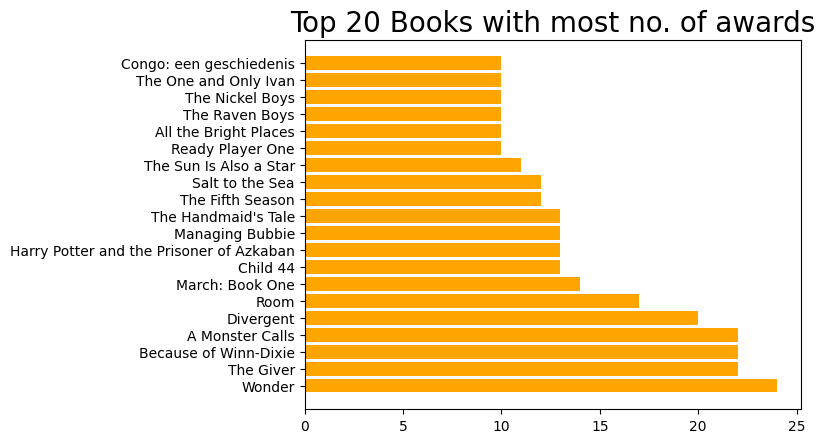

In [18]:
# Get titles and award counts for the top 20 books with most awards
no_of_awards = df['awards'].str.replace('[','').str.replace(']','').str.split(',').apply(lambda lst: len([x.strip() for x in lst if x.strip() != ''])).sort_values(ascending = False).head(20)
ax = plt.barh(width= no_of_awards.values, y = df.loc[no_of_awards.index,'title'], color = 'orange')
plt.plot(figsize = (10,10), ax =ax)
plt.title('Top 20 Books with most no. of awards', size = 20);



In [19]:
df.language.value_counts()

language
English                          8032
Arabic                            127
Spanish                           116
German                             95
French                             91
Portuguese                         68
Indonesian                         60
Turkish                            49
Japanese                           39
Greek, Modern (1453-)              36
Italian                            33
Persian                            31
Malay                              25
Dutch                              23
Russian                            21
Bengali                            21
Bulgarian                          20
Polish                             18
Filipino; Pilipino                 18
Urdu                               17
Serbian                            16
Romanian                           15
Czech                              13
Norwegian                           9
Georgian                            8
Tamil                               7
Cro

# Feature Engineering

In [20]:
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
13885,19189005-the-river-folk,The River Folk,NaN,Margaret Dickinson,4.22,...,[],https://i.gr-assets.com/images/S/compressed.ph...,34,1,3.11
18291,3606415-how-to-survive-in-your-native-land,How to Survive in Your Native Land,NaN,James Herndon,4.15,...,[],https://i.gr-assets.com/images/S/compressed.ph...,42,1,5.87


In [21]:
# we will use only few columns
df = df[['title','author','description','genres', 'coverImg']]
df.head()

,title,author,description,genres,coverImg
13885,The River Folk,Margaret Dickinson,The River Folk is a spellbinding story of Linc...,['Historical Fiction'],https://i.gr-assets.com/images/S/compressed.ph...
18291,How to Survive in Your Native Land,James Herndon,In How to Survive in Your Native Land James He...,"['Education', 'Nonfiction', 'Teaching', 'Memoir']",https://i.gr-assets.com/images/S/compressed.ph...
2003,How to make most of Ramadan,"Darussalam (Editor), Darussalam",Narrated Abu Hurairah: Allah's Apostle (pbuh) ...,['Islam'],https://i.gr-assets.com/images/S/compressed.ph...
23510,"Satires, Epistles and Ars Poetica","Horatius, H.R. Fairclough (Translator)","In the two books of ""Satires"" Horace is a mode...","['Poetry', 'Classics', 'Philosophy', 'Nonficti...",https://i.gr-assets.com/images/S/compressed.ph...
14990,Scorched,Laura Griffin (Goodreads Author),Kelsey Quinn set out to trace a murder victim....,"['Romantic Suspense', 'Romance', 'Suspense', '...",https://i.gr-assets.com/images/S/compressed.ph...


In [22]:
#check null values in filtered df
df.isna().sum()

title            0
author           0
description    294
genres           0
coverImg       121
dtype: int64

In [23]:
#drop null
df.dropna(inplace = True)

In [24]:
#check null again
df.isna().sum()

title          0
author         0
description    0
genres         0
coverImg       0
dtype: int64

In [25]:
df.shape

(9618, 5)

In [26]:
# preprocess genres
df.genres = df.genres.str.lower().str.replace(' ','').apply(eval).str.join(' ') #removing spaces between words

In [27]:
# preprocess author
df['author'] = df['author'].str.replace(' ','').str.replace(',',' ') #removing spaces between name and surname 

df['author'] = df['author'].str.replace(r'\(.+\)','',regex = True).str.replace(r'\s+',' ',regex = True).str.strip() #removing parentheses

df['author'] = df['author'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip() #removing punctuations



In [28]:
# preprocessing description
stop = r'\b('+ '|'.join(stopwords.words('english'))+r')\b'  # stopwords with regex

df['description'] = df['description'].str.lower().str.replace(stop,' ',regex = True) # removing stopwords




In [29]:
#create new column : tags = author + description + genres
df['tags'] = df['author'] + ' ' + df['description'] + ' ' + df['genres']
df.head()

,title,author,description,genres,coverImg,tags
13885,The River Folk,margaretdickinson,river folk spellbinding story lincolns...,historicalfiction,https://i.gr-assets.com/images/S/compressed.ph...,margaretdickinson river folk spellbindin...
18291,How to Survive in Your Native Land,jamesherndon,survive native land james herndon de...,education nonfiction teaching memoir,https://i.gr-assets.com/images/S/compressed.ph...,jamesherndon survive native land jam...
2003,How to make most of Ramadan,darussalam darussalam,narrated abu hurairah: allah' apostle (pbuh) ...,islam,https://i.gr-assets.com/images/S/compressed.ph...,darussalam darussalam narrated abu hurairah: a...
23510,"Satires, Epistles and Ars Poetica",horatius hrfairclough,"two books ""satires"" horace moderate ...",poetry classics philosophy nonfiction history ...,https://i.gr-assets.com/images/S/compressed.ph...,"horatius hrfairclough two books ""satires..."
14990,Scorched,lauragriffin,kelsey quinn set trace murder victim. ...,romanticsuspense romance suspense contemporary...,https://i.gr-assets.com/images/S/compressed.ph...,lauragriffin kelsey quinn set trace murd...


In [30]:
#preprocess tags
df['tags'] = df['tags'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.replace(r'\s+',' ',regex = True).str.strip()  #removing punctuations

In [31]:
#stemming
ps = PorterStemmer()
df['tags'] =df['tags'].str.split(' ').apply(lambda x:[ps.stem(i) for i in x])

df.tags = df.tags.str.join(' ')  # list to text

In [32]:
#saving data
data.loc[df.index,['title','author','coverImg']].to_parquet('books_modified.parquet', index = False, compression = 'brotli')

In [33]:
#tag vectorization
tfidf = TfidfVectorizer(max_features=4000, stop_words = 'english')
vec = tfidf.fit_transform(df['tags']).toarray().astype(np.float16)

In [34]:
#vec size
vec.nbytes/1024/1024

73.3795166015625

In [35]:
x = tfidf.transform(["a young adult vampire-romance novel by Stephenie Meyer, launching a massive franchise including four main books and a five-film saga. It follows 17-year-old Bella Swan as she moves to Forks, Washington, falling for Edward Cullen, a 104-year-old vampire. The story focuses on their dangerous romance, Edward's vegetarian vampire family, and threats from hostile vampires."]).toarray().astype(np.float16)

In [36]:
#let's get most similar books
similar = list(enumerate(cosine_similarity(x,vec)[0]))

In [37]:
#top 10 indices of similar books
indices = [i for i, j in sorted(similar, key = lambda x :x[1], reverse=True)[:10]]

In [38]:
#metadata of similar books
pd.read_parquet('books_modified.parquet').iloc[indices]

,title,author,coverImg
2449,The Ghost Of Ellen Dower,Earl B. Pilgrim,https://i.gr-assets.com/images/S/compressed.ph...
4204,600 Hours of Edward,Craig Lancaster (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
151,ஆயிஷா [Ayeesha],Era. Natarasan,https://i.gr-assets.com/images/S/compressed.ph...
3724,"The Perfect King: The Life of Edward III, Fath...",Ian Mortimer (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
1074,Dear Edward,Ann Napolitano (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
6305,Genesis,Miranda Nading (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
3680,Fullmetal Alchemist: The Land of Sand,"Makoto Inoue, Hiromu Arakawa (Illustrator), Al...",https://i.gr-assets.com/images/S/compressed.ph...
748,Jack of Hearts,Candace C. Bowen (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
7898,The Life and Diary of David Brainerd,"David Brainerd, Jonathan Edwards (Editor)",https://i.gr-assets.com/images/S/compressed.ph...
9613,The Hummingbird Effect,S. P. Jordans,https://i.gr-assets.com/images/S/compressed.ph...


In [39]:
joblib.dump(tfidf, 'tfidf.joblib')

['tfidf.joblib']

In [40]:
#saving book vector
np.savez_compressed("book_vec.npz", vec=vec)